Best x = -0.2832196305925173
Minimum = -9.800367458085244


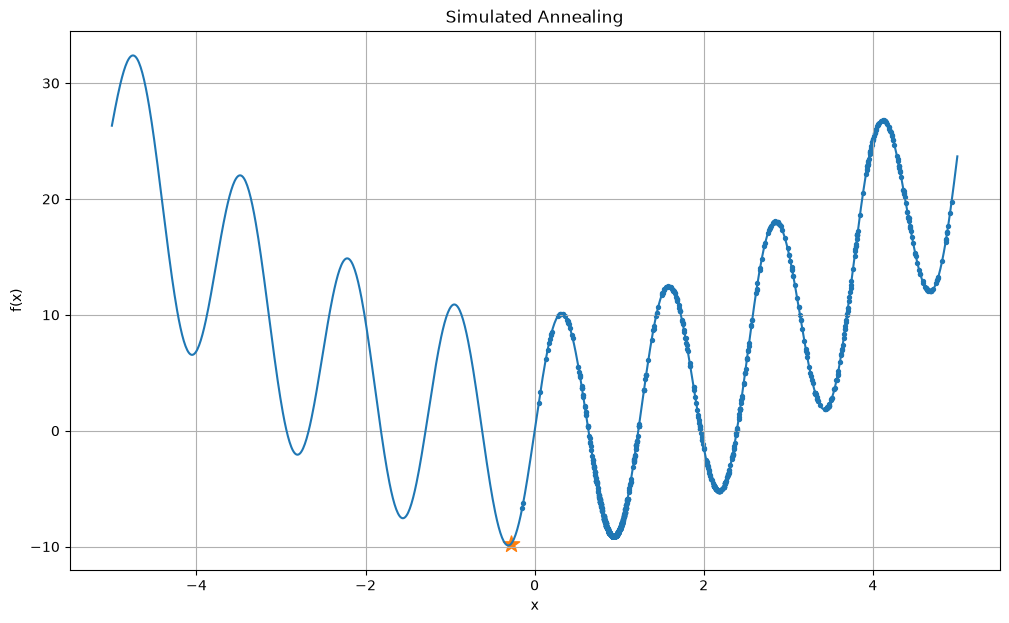

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math


def f(x):
    return x**2 + 10 * np.sin(5 * x)


current_x = 4.0

best_x = current_x
best_value = f(current_x)

temperature = 200.0
cooling_rate = 0.995

path = [current_x]

while temperature > 0.01:

    new_x = current_x + random.uniform(-0.5, 0.5)
    new_x = max(-5.0, min(5.0, new_x))

    current_value = f(current_x)
    new_value = f(new_x)

    delta = new_value - current_value

    if delta < 0:

        current_x = new_x

    else:

        probability = math.exp(-delta / temperature)

        if random.random() < probability:
            current_x = new_x

    if f(current_x) < best_value:

        best_x = current_x
        best_value = f(current_x)

    path.append(current_x)

    temperature *= cooling_rate


print("Best x =", best_x)
print("Minimum =", best_value)


x_values = np.linspace(-5, 5, 1000)
y_values = f(x_values)

plt.figure(figsize=(12, 7))

plt.plot(x_values, y_values)

path_values = [f(x) for x in path]

plt.scatter(
    path,
    path_values,
    s=8
)

plt.scatter(
    best_x,
    best_value,
    s=150,
    marker="*"
)

plt.xlabel("x")
plt.ylabel("f(x)")

plt.title("Simulated Annealing")

plt.grid(True)

plt.show()